# INFLAÇÃO BRASIL - GERAL E GRUPOS

In [70]:
# Importação e leitura dos arquivos

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

ipca_anual = pd.read_csv('data/ipca_main_yearly.csv')
ipca_raw = pd.read_csv('data/ipca_full_raw.csv')
ipca_grupos = pd.read_csv('data/ipca_main_groups.csv')

In [71]:
print(ipca_anual.head())

   year                      group  value
0  2006      Alimentação e bebidas   2.56
1  2006                Comunicação  -1.68
2  2006                   Educação   0.43
3  2006                  Habitação   0.82
4  2006  Saúde e cuidados pessoais   1.76


In [72]:
print(ipca_raw.head())

         date  year  month  category_id      category  value
0  2006-07-01  2006      7         7169  Índice geral   0.19
1  2006-08-01  2006      8         7169  Índice geral   0.05
2  2006-09-01  2006      9         7169  Índice geral   0.21
3  2006-10-01  2006     10         7169  Índice geral   0.33
4  2006-11-01  2006     11         7169  Índice geral   0.31


In [73]:
print(ipca_grupos.head())

         date  year  month  category_id                 category  value  \
0  2006-07-01  2006      7         7170  1.Alimentação e bebidas   0.09   
1  2006-08-01  2006      8         7170  1.Alimentação e bebidas   0.07   
2  2006-09-01  2006      9         7170  1.Alimentação e bebidas   0.08   
3  2006-10-01  2006     10         7170  1.Alimentação e bebidas   0.88   
4  2006-11-01  2006     11         7170  1.Alimentação e bebidas   1.05   

                   group  
0  Alimentação e bebidas  
1  Alimentação e bebidas  
2  Alimentação e bebidas  
3  Alimentação e bebidas  
4  Alimentação e bebidas  


In [74]:
print(ipca_anual.info())
print("================================")
print(ipca_raw.info())
print("=================================")
print(ipca_grupos.info())

<class 'pandas.DataFrame'>
RangeIndex: 120 entries, 0 to 119
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   year    120 non-null    int64  
 1   group   120 non-null    str    
 2   value   120 non-null    float64
dtypes: float64(1), int64(1), str(1)
memory usage: 2.9 KB
None
<class 'pandas.DataFrame'>
RangeIndex: 108138 entries, 0 to 108137
Data columns (total 6 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   date         108138 non-null  str    
 1   year         108138 non-null  int64  
 2   month        108138 non-null  int64  
 3   category_id  108138 non-null  int64  
 4   category     108138 non-null  str    
 5   value        107186 non-null  float64
dtypes: float64(1), int64(3), str(2)
memory usage: 5.0 MB
None
<class 'pandas.DataFrame'>
RangeIndex: 2106 entries, 0 to 2105
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------     

In [75]:
# Validação dos dados
print("Duplicados em ipca_anual:", ipca_anual.duplicated().sum())
print("Duplicados em ipca_raw:", ipca_raw.duplicated().sum())
print("Duplicados em ipca_grupos:", ipca_grupos.duplicated().sum())

print("Valores nulos em ipca_anual:\n", ipca_anual.isnull().sum())
print("Valores nulos em ipca_raw:\n", ipca_raw.isnull().sum())
print("Valores nulos em ipca_grupos:\n", ipca_grupos.isnull().sum())

Duplicados em ipca_anual: 0
Duplicados em ipca_raw: 0
Duplicados em ipca_grupos: 0
Valores nulos em ipca_anual:
 year     0
group    0
value    0
dtype: int64
Valores nulos em ipca_raw:
 date             0
year             0
month            0
category_id      0
category         0
value          952
dtype: int64
Valores nulos em ipca_grupos:
 date           0
year           0
month          0
category_id    0
category       0
value          0
group          0
dtype: int64


In [76]:
# Valores nulos em ipca_raw motivo na coluna 'value'

null_rows = ipca_raw[ipca_raw.isnull().any(axis=1)]
print("Linhas com valores nulos em ipca_raw:")
print(null_rows)

Linhas com valores nulos em ipca_raw:
             date  year  month  category_id                 category  value
30798  2012-01-01  2012      1        41128  1101075.Feijão - branco    NaN
30799  2012-02-01  2012      2        41128  1101075.Feijão - branco    NaN
30800  2012-03-01  2012      3        41128  1101075.Feijão - branco    NaN
30801  2012-04-01  2012      4        41128  1101075.Feijão - branco    NaN
30802  2012-05-01  2012      5        41128  1101075.Feijão - branco    NaN
...           ...   ...    ...          ...                      ...    ...
65493  2018-04-01  2018      4        41131    1108170.Peixe - mandi    NaN
69510  2018-01-01  2018      1       107683       8104005.Autoescola    NaN
69511  2018-02-01  2018      2       107683       8104005.Autoescola    NaN
69512  2018-03-01  2018      3       107683       8104005.Autoescola    NaN
69513  2018-04-01  2018      4       107683       8104005.Autoescola    NaN

[952 rows x 6 columns]


In [77]:
# Analise final de validação de dados
print("Porcentagem de linhas com valores nulos em ipca_raw:", len(null_rows) / len(ipca_raw) * 100)
print("Porcentagem de linhas com valores nulos na coluna category com 'Índice geral':", len(null_rows[null_rows['category'] == 'Índice geral']) / len(ipca_raw) * 100)

Porcentagem de linhas com valores nulos em ipca_raw: 0.8803565814052415
Porcentagem de linhas com valores nulos na coluna category com 'Índice geral': 0.0


In [78]:
# Inflação total por ano
ipca_total_anual = ipca_raw[ipca_raw['category'] == 'Índice geral'].groupby('year')['value'].sum().reset_index()
ipca_total_anual = ipca_total_anual[ipca_total_anual['year'] != 2006]
ipca_total_anual

,year,value
1,2007,4.37
2,2008,5.75
3,2009,4.23
4,2010,5.76
5,2011,6.32
6,2012,5.69
7,2013,5.76
8,2014,6.23
9,2015,10.19
10,2016,6.12


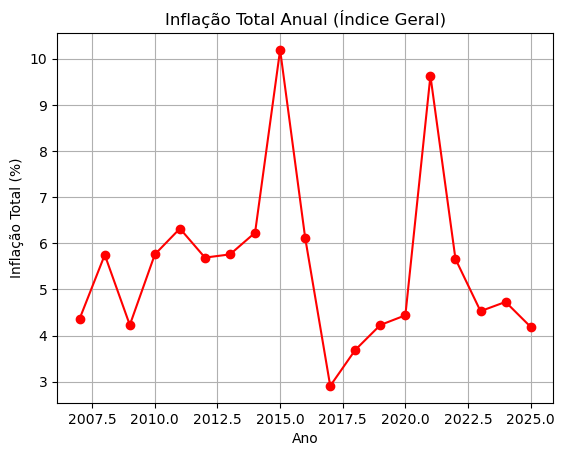

In [79]:
plt.plot(ipca_total_anual['year'], ipca_total_anual['value'], color='red', marker='o')
plt.xlabel('Ano')
plt.ylabel('Inflação Total (%)')
plt.title('Inflação Total Anual (Índice Geral)')
plt.grid()
plt.show()

In [80]:
# Menor e maior inflação anual
min_inflacao = ipca_total_anual['value'].min()
max_inflacao = ipca_total_anual['value'].max()
print(f"Menor inflação anual: {min_inflacao:.2f}%")
print(f"Maior inflação anual: {max_inflacao:.2f}%")

Menor inflação anual: 2.91%
Maior inflação anual: 10.19%


In [81]:
# Comparação média e deviação padrão entre os ultimos 10 anos e os anos anteriores
ipca_ultimos_10_anos = ipca_total_anual[ipca_total_anual['year'] >= 2016]
ipca_anteriores = ipca_total_anual[ipca_total_anual['year'] < 2016]
media_ultimos_10_anos = ipca_ultimos_10_anos['value'].mean()
media_anteriores = ipca_anteriores['value'].mean()
desvio_ultimos_10_anos = ipca_ultimos_10_anos['value'].std()
desvio_anteriores = ipca_anteriores['value'].std()
print(f"Média dos últimos 10 anos: {media_ultimos_10_anos:.2f}%")
print(f"Média dos anos anteriores: {media_anteriores:.2f}%")
print(f"Desvio padrão dos últimos 10 anos: {desvio_ultimos_10_anos:.2f}%")
print(f"Desvio padrão dos anos anteriores: {desvio_anteriores:.2f}%")

Média dos últimos 10 anos: 5.01%
Média dos anos anteriores: 6.03%
Desvio padrão dos últimos 10 anos: 1.86%
Desvio padrão dos anos anteriores: 1.72%


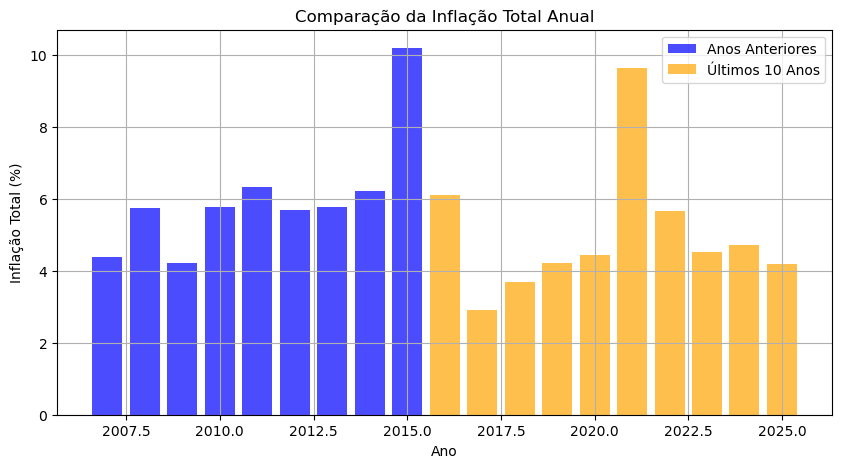

In [82]:
# Plot comparativo entre os últimos 10 anos e os anos anteriores
plt.figure(figsize=(10, 5))
plt.bar(ipca_anteriores['year'], ipca_anteriores['value'], color='blue', label='Anos Anteriores', alpha=0.7)
plt.bar(ipca_ultimos_10_anos['year'], ipca_ultimos_10_anos['value'], color='orange', label='Últimos 10 Anos', alpha=0.7)
plt.xlabel('Ano')
plt.ylabel('Inflação Total (%)')
plt.title('Comparação da Inflação Total Anual')
plt.legend()    
plt.grid()
plt.show()

TypeError: object of type 'module' has no len()

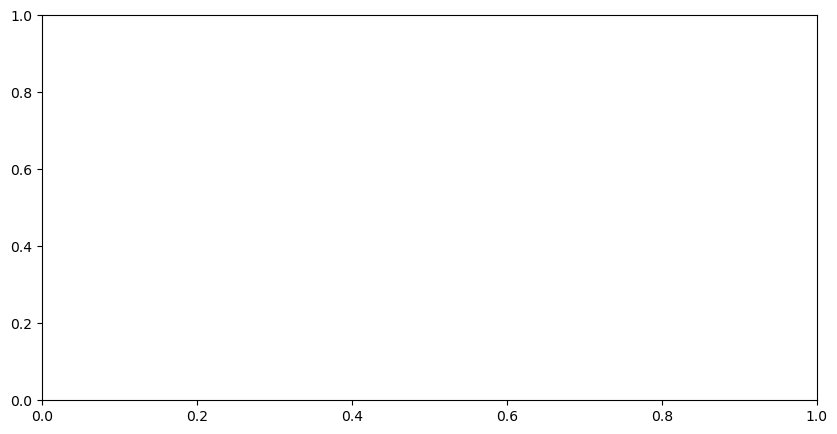

In [84]:
# Exemplo visual didatico de std
plt.figure(figsize=(10, 5))
plt.bar(periods, means, color=colors, alpha=0.7)
plt.errorbar(periods, means, yerr=[desvio_anteriores, desvio_ultimos_10_anos], fmt='none', ecolor='black', capsize=5)
plt.ylabel('Inflação Total (%)')
plt.title('Comparação da Inflação Total Anual com Desvio Padrão')
plt.legend(periods)
plt.grid()
plt.show()